# Data Preparation: Medical Procedure Loan Scorecard

**Objective:** Clean, aggregate, merge, and filter features for credit scorecard development.

**Steps:**
1. **Application Data Cleaning** — drop invalid/noisy columns
2. **Bureau Data Aggregation** — flatten with count, mean, max, sum + create ratios
3. **Combine Data** — merge application + bureau
4. **Correlation Filtering** — drop columns with low correlation to target

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", font_scale=0.9)

In [2]:
app = pd.read_csv('../data/IS453 Group Assignment - Application Data.csv')
bureau = pd.read_csv('../data/IS453 Group Assignment - Bureau Data.csv')

print(f"Application data: {app.shape[0]:,} rows x {app.shape[1]} columns")
print(f"Bureau data:      {bureau.shape[0]:,} rows x {bureau.shape[1]} columns")

Application data: 307,511 rows x 120 columns
Bureau data:      1,716,428 rows x 17 columns


## Step 1: Application Data Cleaning

In [3]:
# Fix DAYS_* columns: take absolute value for interpretability
day_cols = [c for c in app.columns if c.startswith('DAYS_')]
app[day_cols] = app[day_cols].abs()

# Fix DAYS_EMPLOYED: 365243 encodes "unemployed"
app.loc[app['DAYS_EMPLOYED'] == 365243, 'DAYS_EMPLOYED'] = np.nan

# Drop rows where any DAYS_* > 120 years (life expectancy threshold)
# 120 years ≈ 43,830 days (using 365.25 days/year)
max_days = 120 * 365.25
rows_before = len(app)

for col in day_cols:
    app = app[app[col] <= max_days]

rows_dropped = rows_before - len(app)

print(f"Fixed {len(day_cols)} DAYS_* columns (absolute values)")
print(f"DAYS_EMPLOYED NaN count (unemployed): {app['DAYS_EMPLOYED'].isna().sum():,}")
print(f"Dropped {rows_dropped:,} rows with DAYS_* > 120 years (threshold: {max_days:,.0f} days)")
print(f"Remaining rows: {len(app):,}")

Fixed 5 DAYS_* columns (absolute values)
DAYS_EMPLOYED NaN count (unemployed): 0
Dropped 55,375 rows with DAYS_* > 120 years (threshold: 43,830 days)
Remaining rows: 252,136


In [4]:
# Handle outliers in key columns (based on exploration findings)
income_min = app['AMT_INCOME_TOTAL'].min()
income_max = app['AMT_INCOME_TOTAL'].max()
app['AMT_INCOME_TOTAL'] = (app['AMT_INCOME_TOTAL'] - income_min) / (income_max - income_min)
print(f"Min-max scaled AMT_INCOME_TOTAL to [0, 1]")


Min-max scaled AMT_INCOME_TOTAL to [0, 1]


In [5]:
# Drop columns with high missing rate (>50%)
missing = app.isnull().mean()
high_missing = missing[missing > 0.50].index.tolist()

print(f"High missing (>50%): {len(high_missing)} columns")
print(f"\nDropped columns:")
for col in sorted(high_missing):
    print(f"  {col:40s} {missing[col]*100:6.2f}%")

app_clean = app.drop(columns=high_missing)
print(f"\nRemaining columns: {app_clean.shape[1]}")

High missing (>50%): 37 columns

Dropped columns:
  APARTMENTS_AVG                            50.50%
  APARTMENTS_MEDI                           50.50%
  APARTMENTS_MODE                           50.50%
  BASEMENTAREA_AVG                          58.31%
  BASEMENTAREA_MEDI                         58.31%
  BASEMENTAREA_MODE                         58.31%
  COMMONAREA_AVG                            69.76%
  COMMONAREA_MEDI                           69.76%
  COMMONAREA_MODE                           69.76%
  ELEVATORS_AVG                             53.06%
  ELEVATORS_MEDI                            53.06%
  ELEVATORS_MODE                            53.06%
  ENTRANCES_AVG                             50.11%
  ENTRANCES_MEDI                            50.11%
  ENTRANCES_MODE                            50.11%
  EXT_SOURCE_1                              51.90%
  FLOORSMIN_AVG                             67.74%
  FLOORSMIN_MEDI                            67.74%
  FLOORSMIN_MODE                

## Step 2: Bureau Data Aggregation

In [6]:
# Count by credit status
status_counts = bureau.pivot_table(
    index='SK_ID_CURR', columns='CREDIT_ACTIVE', values='SK_ID_BUREAU',
    aggfunc='count', fill_value=0
).add_prefix('num_')
status_counts.columns = [c.lower().replace(' ', '_') for c in status_counts.columns]

# Numeric aggregations
bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    # Count
    total_loans=('SK_ID_BUREAU', 'nunique'),
    
    # Sum
    total_credit_amount=('AMT_CREDIT_SUM', 'sum'),
    total_debt=('AMT_CREDIT_SUM_DEBT', 'sum'),
    total_credit_limit=('AMT_CREDIT_SUM_LIMIT', 'sum'),
    total_overdue=('AMT_CREDIT_SUM_OVERDUE', 'sum'),
    total_prolongations=('CNT_CREDIT_PROLONG', 'sum'),
    
    # Mean
    avg_credit_amount=('AMT_CREDIT_SUM', 'mean'),
    avg_days_credit=('DAYS_CREDIT', 'mean'),
    avg_overdue_days=('CREDIT_DAY_OVERDUE', 'mean'),
    
    # Max
    max_credit_amount=('AMT_CREDIT_SUM', 'max'),
    max_overdue_amount=('AMT_CREDIT_MAX_OVERDUE', 'max'),
    max_overdue_days=('CREDIT_DAY_OVERDUE', 'max'),
    
    # Overdue frequency
    loans_with_overdue=('CREDIT_DAY_OVERDUE', lambda x: (x > 0).sum())
).reset_index()

# Merge status counts
bureau_agg = bureau_agg.merge(status_counts.reset_index(), on='SK_ID_CURR', how='left')

print(f"Bureau aggregated: {bureau_agg.shape[0]:,} applicants x {bureau_agg.shape[1]} features")

Bureau aggregated: 305,811 applicants x 18 features


In [7]:
# Derived ratios
bureau_agg['debt_to_credit'] = bureau_agg['total_debt'] / bureau_agg['total_credit_amount'].replace(0, np.nan)
bureau_agg['overdue_to_debt'] = bureau_agg['total_overdue'] / bureau_agg['total_debt'].replace(0, np.nan)
bureau_agg['credit_utilization'] = bureau_agg['total_debt'] / bureau_agg['total_credit_limit'].replace(0, np.nan)
bureau_agg['prolongation_rate'] = bureau_agg['total_prolongations'] / bureau_agg['total_loans'].replace(0, np.nan)
bureau_agg['overdue_frequency'] = bureau_agg['loans_with_overdue'] / bureau_agg['total_loans'].replace(0, np.nan)

print("Derived ratios:")
ratio_cols = ['debt_to_credit', 'overdue_to_debt', 'credit_utilization', 'prolongation_rate', 'overdue_frequency']
print(bureau_agg[ratio_cols].describe().round(4))

Derived ratios:
       debt_to_credit  overdue_to_debt  credit_utilization  prolongation_rate  \
count     304535.0000      216785.0000        5.651100e+04        305811.0000   
mean           0.2822           0.0022        4.680515e+03             0.0070   
std            0.4319           0.3153        1.751835e+05             0.0623   
min         -175.2892          -0.6242       -2.114574e+04             0.0000   
25%            0.0000           0.0000        1.237500e+00             0.0000   
50%            0.2109           0.0000        7.555600e+00             0.0000   
75%            0.4818           0.0000        4.734130e+01             0.0000   
max            7.7891         104.0000        3.147774e+07             6.0000   

       overdue_frequency  
count        305811.0000  
mean              0.0029  
std               0.0344  
min               0.0000  
25%               0.0000  
50%               0.0000  
75%               0.0000  
max               1.0000  


## Step 3: Combine Data

In [8]:
# Merge (left join to keep all applicants)
df = app_clean.merge(bureau_agg, on='SK_ID_CURR', how='left')

# Drop ID after merge
df = df.drop(columns=['SK_ID_CURR'])

print(f"Merged dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")

# Check missing from bureau join
bureau_missing = df.isnull().mean().sort_values(ascending=False)
bureau_missing = bureau_missing[bureau_missing > 0]
if len(bureau_missing) > 0:
    print(f"\nTop missing features after merge:")
    for col, pct in bureau_missing.head(10).items():
        print(f"  {col:35s} {pct*100:6.2f}%")

Merged dataset: 252,136 rows x 104 columns

Top missing features after merge:
  credit_utilization                   83.21%
  LIVINGAREA_MODE                      49.94%
  LIVINGAREA_AVG                       49.94%
  LIVINGAREA_MEDI                      49.94%
  HOUSETYPE_MODE                       49.91%
  FLOORSMAX_AVG                        49.52%
  FLOORSMAX_MEDI                       49.52%
  FLOORSMAX_MODE                       49.52%
  YEARS_BEGINEXPLUATATION_MODE         48.52%
  YEARS_BEGINEXPLUATATION_AVG          48.52%


## Step 4: Correlation Matrix & Drop Low-Correlation Columns

In [9]:
# Compute correlation with target
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_with_target = df[numeric_cols].corrwith(df['TARGET']).sort_values(ascending=False, key=abs)

print("Top 15 Features by Absolute Correlation with Target:")
for feat, corr in corr_with_target.head(15).items():
    print(f"  {feat:40s} {corr:+.4f}")

Top 15 Features by Absolute Correlation with Target:
  TARGET                                   +1.0000
  avg_days_credit                          +0.0926
  DAYS_EMPLOYED                            -0.0750
  REGION_RATING_CLIENT_W_CITY              +0.0675
  DAYS_BIRTH                               -0.0658
  REGION_RATING_CLIENT                     +0.0651
  DAYS_LAST_PHONE_CHANGE                   -0.0603
  num_active                               +0.0599
  debt_to_credit                           +0.0575
  AMT_GOODS_PRICE                          -0.0503
  FLOORSMAX_AVG                            -0.0495
  FLOORSMAX_MEDI                           -0.0492
  FLOORSMAX_MODE                           -0.0486
  loans_with_overdue                       +0.0440
  REG_CITY_NOT_WORK_CITY                   +0.0434


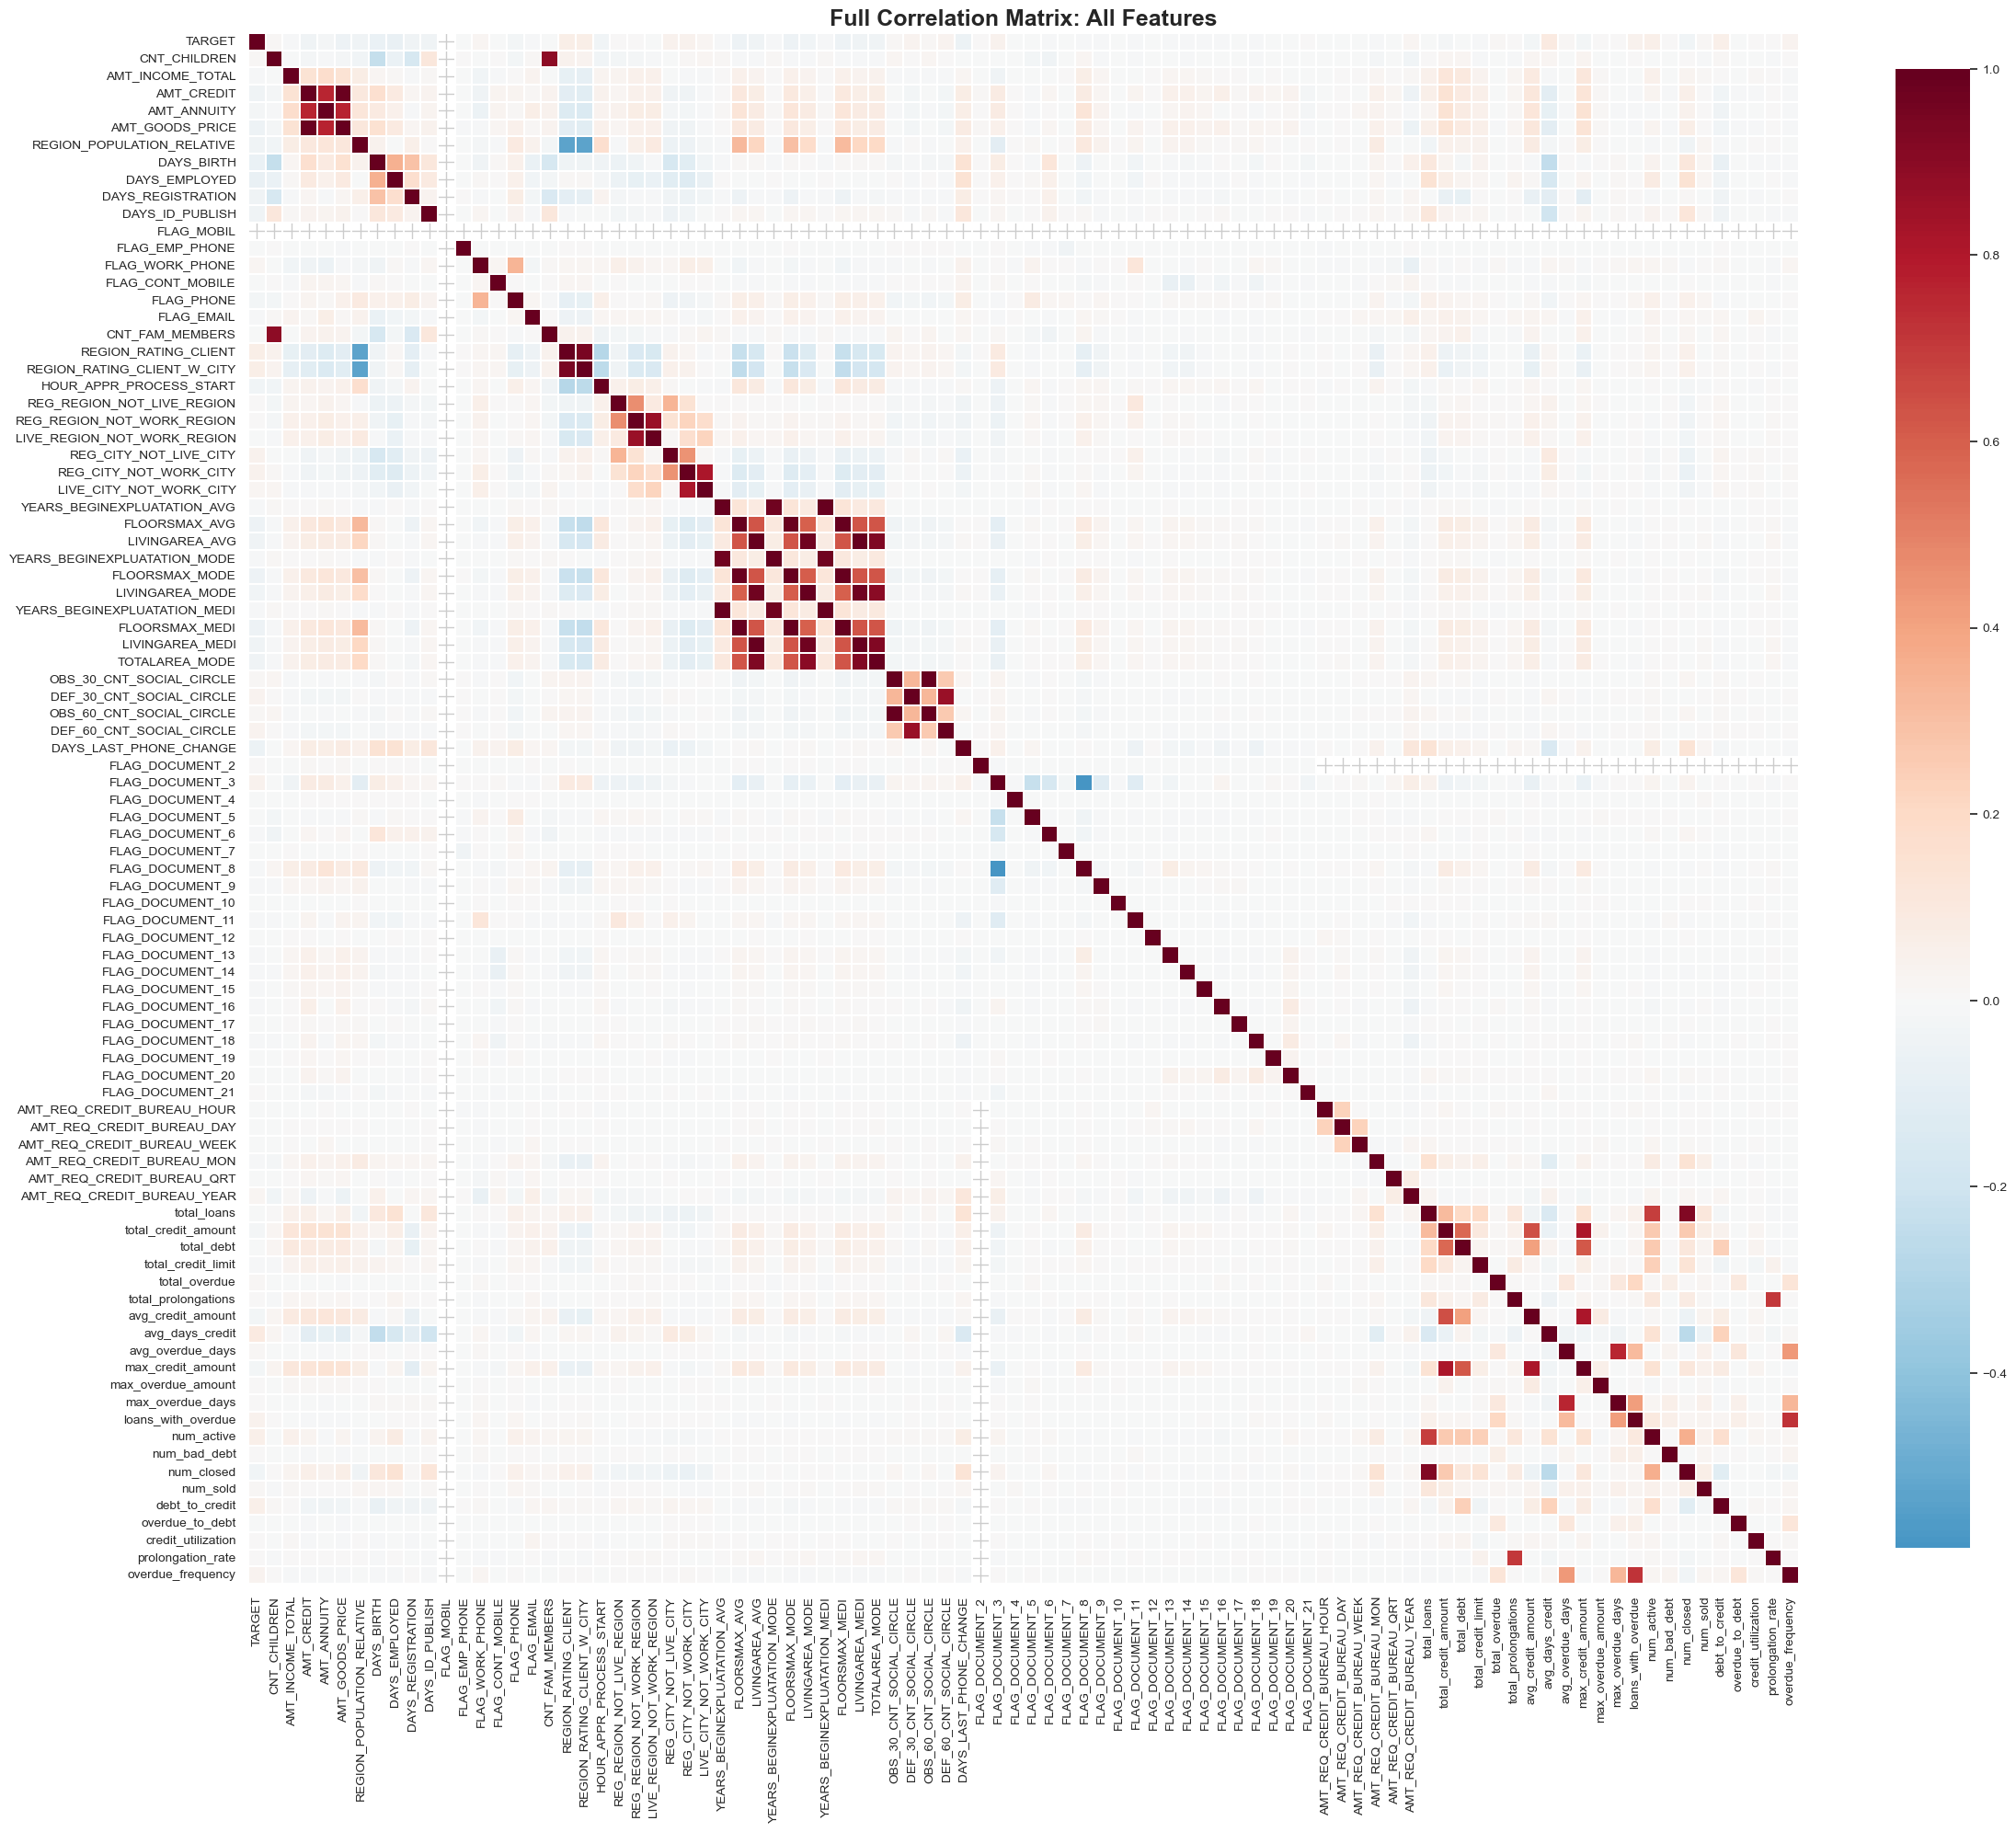


Feature Correlations with TARGET (sorted by absolute value):


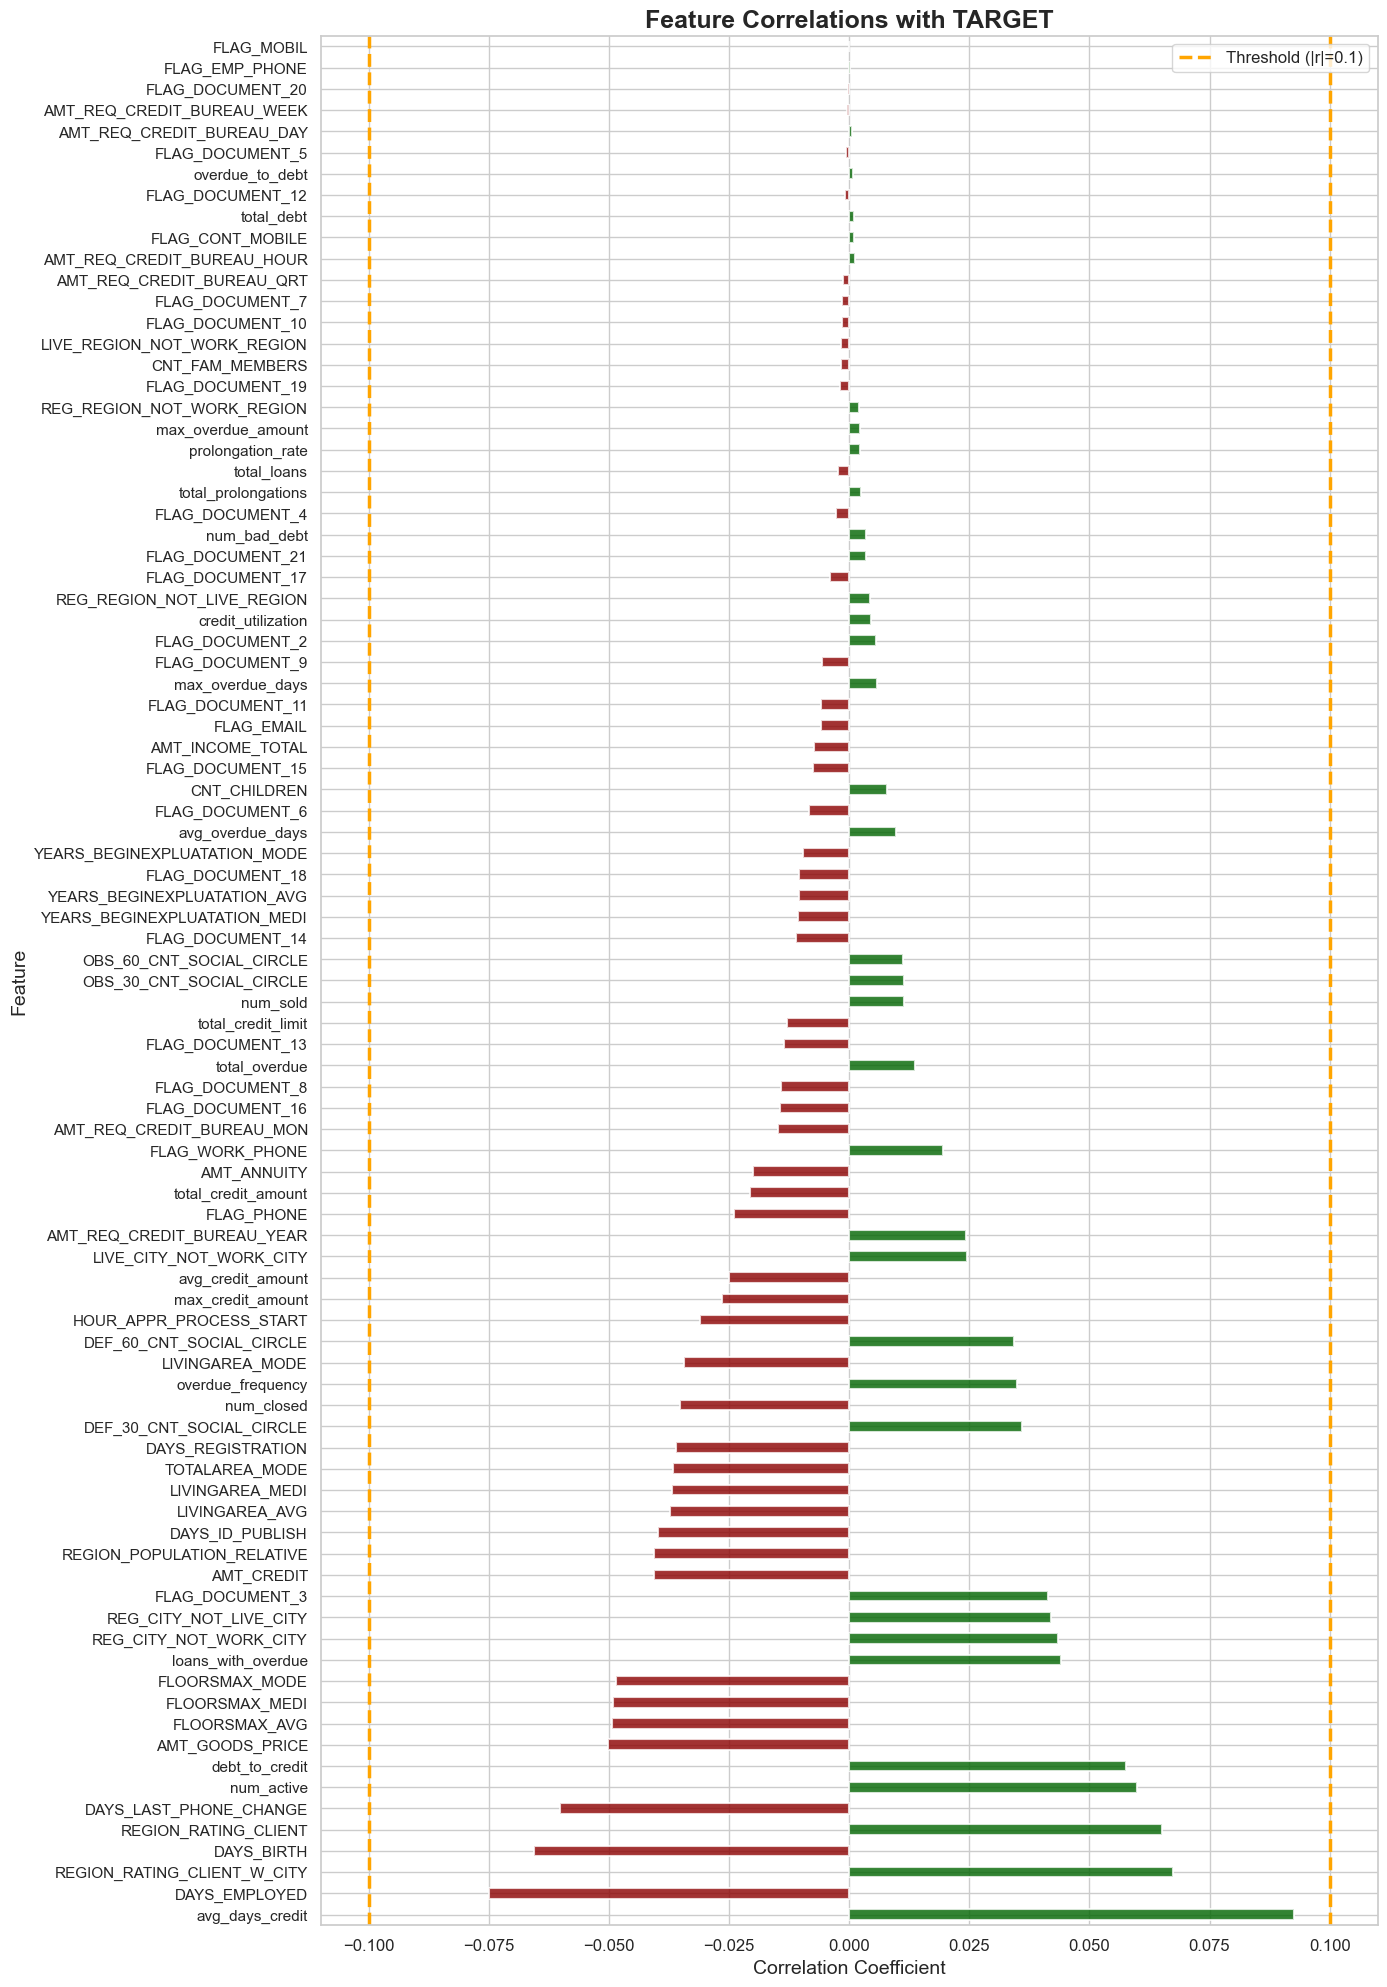

In [10]:
# Full correlation matrix for all numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns
full_corr_matrix = df[numeric_cols].corr()

# Heatmap of all features (full correlation matrix)
plt.figure(figsize=(24, 22))
sns.heatmap(full_corr_matrix, annot=False, cmap='RdBu_r', center=0, 
            square=True, linewidths=0.1, cbar_kws={'shrink': 0.8}, 
            xticklabels=True, yticklabels=True)
plt.title('Full Correlation Matrix: All Features', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

# Bar plot of correlations with target
print("\nFeature Correlations with TARGET (sorted by absolute value):")
print("="*60)
corr_with_target_all = corr_with_target.iloc[1:]  # exclude TARGET itself
colors = ['darkgreen' if x > 0 else 'darkred' for x in corr_with_target_all.values]

plt.figure(figsize=(14, 20))
corr_with_target_all.plot(kind='barh', color=colors, alpha=0.8, linewidth=1.5)
plt.title('Feature Correlations with TARGET', fontsize=18, fontweight='bold')
plt.xlabel('Correlation Coefficient', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.axvline(x=0.1, color='orange', linestyle='--', linewidth=2.5, label='Threshold (|r|=0.1)')
plt.axvline(x=-0.1, color='orange', linestyle='--', linewidth=2.5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=11)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
# Step 1: Drop columns with low absolute correlation to target (threshold: 0.05)
threshold = 0.05
low_corr = corr_with_target[corr_with_target.abs() < threshold]
low_corr_cols = low_corr.index.tolist()
# Remove TARGET itself
low_corr_cols = [c for c in low_corr_cols if c != 'TARGET']

print(f"Step 1: Low Correlation Filtering (|r| < {threshold})")
print(f"{'='*70}")
print(f"Columns dropped: {len(low_corr_cols)}")
if len(low_corr_cols) > 0:
    print(f"\nDropped columns:")
    for col in sorted(low_corr_cols):
        print(f"  {col:40s} {low_corr[col]:+.4f}")

df_low_dropped = df.drop(columns=low_corr_cols)
print(f"\nAfter low correlation filter: {df_low_dropped.shape[0]:,} rows x {df_low_dropped.shape[1]} columns\n")

# Step 2: Drop highly correlated feature pairs (keep higher correlation to target)
print(f"Step 2: Multicollinearity Filtering (|r| > 0.8 between features)")
print(f"{'='*70}")

multicollinearity_threshold = 0.8
numeric_cols_filtered = df_low_dropped.select_dtypes(include=[np.number]).columns
corr_matrix_filtered = df_low_dropped[numeric_cols_filtered].corr()

# Find pairs with high correlation
high_corr_pairs = []
for i in range(len(corr_matrix_filtered.columns)):
    for j in range(i+1, len(corr_matrix_filtered.columns)):
        col1 = corr_matrix_filtered.columns[i]
        col2 = corr_matrix_filtered.columns[j]
        corr_val = abs(corr_matrix_filtered.iloc[i, j])
        
        if corr_val > multicollinearity_threshold and col1 != 'TARGET' and col2 != 'TARGET':
            high_corr_pairs.append({
                'col1': col1,
                'col2': col2,
                'correlation': corr_matrix_filtered.iloc[i, j],
                'corr_to_target_1': corr_with_target.get(col1, 0),
                'corr_to_target_2': corr_with_target.get(col2, 0)
            })

multicollinearity_cols_to_drop = []
if len(high_corr_pairs) > 0:
    print(f"Found {len(high_corr_pairs)} highly correlated pairs (|r| > {multicollinearity_threshold}):\n")
    for idx, pair in enumerate(high_corr_pairs, 1):
        col1, col2 = pair['col1'], pair['col2']
        corr_val = pair['correlation']
        corr1_target = pair['corr_to_target_1']
        corr2_target = pair['corr_to_target_2']
        
        # Drop the one with LOWER correlation to target
        if abs(corr1_target) > abs(corr2_target):
            drop_col = col2
            keep_col = col1
        else:
            drop_col = col1
            keep_col = col2
        
        multicollinearity_cols_to_drop.append(drop_col)
        print(f"Pair {idx}:")
        print(f"  {col1:40s} (r_target={corr1_target:+.4f})")
        print(f"  {col2:40s} (r_target={corr2_target:+.4f})")
        print(f"  Correlation between them: {corr_val:+.4f}")
        print(f"  → Keep: {keep_col} (|r|={abs(corr_with_target.get(keep_col, 0)):+.4f} to target)")
        print(f"  → Drop: {drop_col} (|r|={abs(corr_with_target.get(drop_col, 0)):+.4f} to target)\n")
else:
    print(f"No highly correlated pairs found (|r| > {multicollinearity_threshold})")

df_final = df_low_dropped.drop(columns=multicollinearity_cols_to_drop)

print(f"\n{'='*70}")
print(f"FINAL SUMMARY")
print(f"{'='*70}")
print(f"Step 1 - Low correlation (|r| < {threshold}):        Dropped {len(low_corr_cols)} columns")
print(f"Step 2 - Multicollinearity (|r| > {multicollinearity_threshold}): Dropped {len(multicollinearity_cols_to_drop)} columns")
print(f"\nMerged dataset:    {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Final dataset:     {df_final.shape[0]:,} rows x {df_final.shape[1]} columns")
print(f"Total dropped:     {len(low_corr_cols) + len(multicollinearity_cols_to_drop)} columns")

# Save final dataset
df_final.to_csv('../data/prepared_scorecard_data.csv', index=False)
print(f"\nSaved to: prepared_scorecard_data.csv")

Step 1: Low Correlation Filtering (|r| < 0.05)
Columns dropped: 79

Dropped columns:
  AMT_ANNUITY                              -0.0200
  AMT_CREDIT                               -0.0407
  AMT_INCOME_TOTAL                         -0.0073
  AMT_REQ_CREDIT_BUREAU_DAY                +0.0006
  AMT_REQ_CREDIT_BUREAU_HOUR               +0.0012
  AMT_REQ_CREDIT_BUREAU_MON                -0.0149
  AMT_REQ_CREDIT_BUREAU_QRT                -0.0012
  AMT_REQ_CREDIT_BUREAU_WEEK               -0.0004
  AMT_REQ_CREDIT_BUREAU_YEAR               +0.0242
  CNT_CHILDREN                             +0.0077
  CNT_FAM_MEMBERS                          -0.0018
  DAYS_ID_PUBLISH                          -0.0399
  DAYS_REGISTRATION                        -0.0361
  DEF_30_CNT_SOCIAL_CIRCLE                 +0.0359
  DEF_60_CNT_SOCIAL_CIRCLE                 +0.0342
  FLAG_CONT_MOBILE                         +0.0010
  FLAG_DOCUMENT_10                         -0.0015
  FLAG_DOCUMENT_11                         -0.00


Saved to: prepared_scorecard_data.csv


In [12]:
# FAIR LENDING COMPLIANCE: Drop Protected Class Features
# Ethical AI requirement: Features violating fair lending principles must be excluded

fair_lending_violations = {
    'CODE_GENDER': 'Gender (direct discrimination - Equal Credit Opportunity Act)',
    'DAYS_BIRTH': 'Age (age discrimination in lending - ECOA protects credit applicants)',
    'NAME_FAMILY_STATUS': 'Marital status (protected - ECOA, Fair Housing Act)',
}

print('Fair Lending Compliance: Dropping Protected Class Features')
print('='*80)
print('Features violating fair lending principles:')
for col, reason in fair_lending_violations.items():
    if col in df_final.columns:
        print(f'  - {col:30s} | {reason}')

# Drop fair lending violation columns
cols_to_drop_fair_lending = [col for col in fair_lending_violations.keys() if col in df_final.columns]
df_final = df_final.drop(columns=cols_to_drop_fair_lending)

print(f'Dropped {len(cols_to_drop_fair_lending)} features for fair lending compliance')
print(f'Final dataset: {df_final.shape[0]:,} rows x {df_final.shape[1]} columns')
print('Remaining features ('+ str(df_final.shape[1]) + '):')
for col in sorted(df_final.columns):
    print(f'  {col}')

# Save updated final dataset
df_final.to_csv('../data/prepared_scorecard_data.csv', index=False)
print('Updated and saved to: prepared_scorecard_data.csv')


Fair Lending Compliance: Dropping Protected Class Features
Features violating fair lending principles:
  - CODE_GENDER                    | Gender (direct discrimination - Equal Credit Opportunity Act)
  - DAYS_BIRTH                     | Age (age discrimination in lending - ECOA protects credit applicants)
  - NAME_FAMILY_STATUS             | Marital status (protected - ECOA, Fair Housing Act)
Dropped 3 features for fair lending compliance
Final dataset: 252,136 rows x 21 columns
Remaining features (21):
  AMT_GOODS_PRICE
  DAYS_EMPLOYED
  DAYS_LAST_PHONE_CHANGE
  EMERGENCYSTATE_MODE
  FLAG_MOBIL
  FLAG_OWN_CAR
  FLAG_OWN_REALTY
  HOUSETYPE_MODE
  NAME_CONTRACT_TYPE
  NAME_EDUCATION_TYPE
  NAME_HOUSING_TYPE
  NAME_INCOME_TYPE
  NAME_TYPE_SUITE
  OCCUPATION_TYPE
  ORGANIZATION_TYPE
  REGION_RATING_CLIENT_W_CITY
  TARGET
  WEEKDAY_APPR_PROCESS_START
  avg_days_credit
  debt_to_credit
  num_active


Updated and saved to: prepared_scorecard_data.csv
